### Hierarchical multi-agent 
-  An AI framework where autonomous agents are organized into a tiered "chain of command" to tackle complex tasks.
-  Instead of a single AI trying to handle everything, high-level agents process strategy, mid-level agents manage planning, and low-level agents execute narrow tasks




This example takes a complex user request like:

Research payment failures, inspect backend design, and create a final technical report.

-    The Top Supervisor decides which department should work.

- Each Department Supervisor decides which specialized worker node should work.

- Each Worker Agent is a create_react_agent with its own tools.

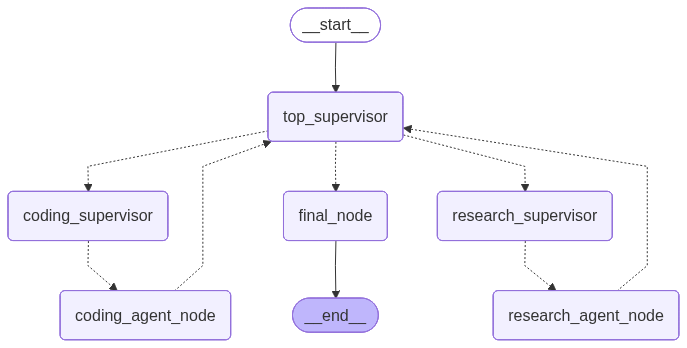

In [57]:
from typing import TypedDict, Literal

from dotenv import load_dotenv
import os

from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain_groq import ChatGroq

from langgraph.graph import StateGraph, START, END
from langgraph.types import Command



In [58]:
# ## 1. Load Environment Variables



# %%
load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")

if not groq_api_key:
    raise ValueError("GROQ_API_KEY is missing. Add it to your .env file.")

os.environ["GROQ_API_KEY"] = groq_api_key

In [59]:
# ## 2. Create the LLM
#
# This LLM is shared by all worker agents.


# %%
llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
)

In [60]:
# ## 3. Define the Graph State
#
# State is the shared memory passed between nodes.
#
# It stores:
# - the original user request
# - research findings
# - coding findings
# - final answer


# %%
class AgentState(TypedDict):
    user_request: str
    research_notes: str
    coding_notes: str
    final_answer: str

In [61]:
# ## 4. Define Research Tools
#
# These tools are available only to the research agent.
#
# In this example, they are mock tools.
# Later, you can replace them with real web search, RAG, or database tools.



@tool
def web_search_tool(query: str) -> str:
    """
    Search public payment knowledge.
    Use this when you need general payment failure information.
    """
    return f"""
Web Search Result for: {query}

Common payment failure patterns:
- API timeout can happen after bank authorization.
- User may see payment failed even if authorization succeeded.
- Duplicate charges are often duplicate authorizations, not settled charges.
- Refund delays usually happen when settlement status is still pending.
"""


@tool
def transaction_lookup_tool(transaction_id: str) -> str:
    """
    Look up transaction status from the payment database.
    Use this when you need authorization, settlement, duplicate charge, or refund status.
    """
    return f"""
Transaction Lookup Result for: {transaction_id}

transaction_id: {transaction_id}
authorization_status: AUTHORIZED
checkout_response: TIMEOUT
settlement_status: PENDING
duplicate_authorization: TRUE
refund_status: WAITING_FOR_SETTLEMENT
"""



# ## 5. Define Coding Tools
#
# These tools are available only to the coding agent.
#
# The coding agent uses them to inspect backend logic and suggest tests.



@tool
def code_search_tool(query: str) -> str:
    """
    Search backend source code.
    Use this when you need to inspect payment service logic.
    """
    return f"""
Code Search Result for: {query}

Found in PaymentService.java:

try:
    response = paymentGateway.authorize(request)
except TimeoutException:
    return PaymentResult(status="FAILED")

Potential issue:
- Code marks payment as FAILED immediately after timeout.
- It does not verify whether authorization succeeded at the gateway.
"""


@tool
def test_case_tool(query: str) -> str:
    """
    Generate test cases for payment failure scenarios.
    Use this when you need validation scenarios.
    """
    return f"""
Test Case Result for: {query}

Recommended test cases:
1. Gateway authorization succeeds but checkout API times out.
2. Duplicate authorization appears for the same customer and amount.
3. Refund is requested while settlement is still pending.
4. Refund is processed only after settlement confirmation.
"""


In [62]:
# ## 6. Create the Research Worker Agent
#
# This is an LLM agent with research tools.
#
# It can call:
# - `web_search_tool`
# - `transaction_lookup_tool`


# %%
research_worker_agent = create_agent(
    model=llm,
    tools=[web_search_tool, transaction_lookup_tool],
    system_prompt="""
You are a Research Agent.

Your job:
- Investigate the user's payment issue.
- Use the available tools when helpful.
- Focus on facts, transaction status, and likely causes.
- Return concise research notes.
""",
)

In [63]:
# ## 7. Create the Coding Worker Agent
#
# This is an LLM agent with coding tools.
#
# It can call:
# - `code_search_tool`
# - `test_case_tool`


# %%
coding_worker_agent = create_agent(
    model=llm,
    tools=[code_search_tool, test_case_tool],
    system_prompt="""
You are a Coding Analysis Agent.

Your job:
- Analyze possible backend logic issues.
- Use code_search_tool to inspect code behavior.
- Use test_case_tool to propose validation scenarios.
- Return concise coding notes.
""",
)

In [64]:
# ## 8. Create the Final Report Writer Agent
#
# This agent does not need tools.
#
# Its job is to synthesize research and coding findings into one final report.
#
# It should not invent facts.



writer_agent = create_agent(
    model=llm,
    tools=[],
    system_prompt="""
You are an expert technical report writer.

Combine findings from multiple teams into one professional report.

Rules:
- Do not invent information.
- Base your answer only on the provided research and coding notes.
- Write clearly and concisely.
""",
)


In [65]:
# ## 9. Top Supervisor Node
#
# The top supervisor controls the overall workflow.
#
# It does not call the LLM.
#
# Routing logic:
# - If research is empty, go to research supervisor.
# - Else if coding notes are empty, go to coding supervisor.
# - Else go to final node.


# %%
def top_supervisor(
    state: AgentState,
) -> Command[Literal["research_supervisor", "coding_supervisor", "final_node"]]:

    if not state.get("research_notes"):
        return Command(goto="research_supervisor")

    if not state.get("coding_notes"):
        return Command(goto="coding_supervisor")

    return Command(goto="final_node")


In [66]:
# ## 10. Research Supervisor Node
#
# This is the middle-level supervisor for the research team.
#
# In this simple example, it has one worker:
# - `research_agent_node`
#
# Later, you can add more research workers like:
# - web research agent
# - RAG research agent
# - SQL research agent



def research_supervisor(
    state: AgentState,
) -> Command[Literal["research_agent_node"]]:

    print("Research supervisor called")
    return Command(goto="research_agent_node")

In [67]:
# ## 11. Research Agent Node
#
# This node calls the LLM research worker agent.
#
# The research worker can use tools to investigate the payment issue.
#
# Output is saved into:
# - `research_notes`
#
# Then control returns to:
# - `top_supervisor`


# %%
def research_agent_node(
    state: AgentState,
) -> Command[Literal["top_supervisor"]]:

    print("Research agent called")

    result = research_worker_agent.invoke(
        {
            "messages": [
                HumanMessage(
                    content=f"""
User request:
{state["user_request"]}

Investigate the payment issue.

Use the available tools if useful.
Assume transaction_id is TXN123.
"""
                )
            ]
        }
    )

    research_notes = result["messages"][-1].content

    return Command(
        update={"research_notes": research_notes},
        goto="top_supervisor",
    )


In [68]:
# ## 12. Coding Supervisor Node
#
# This is the middle-level supervisor for the coding team.
#
# In this simple example, it has one worker:
# - `coding_agent_node`
#
# Later, you can add more coding workers like:
# - backend agent
# - frontend agent
# - testing agent



def coding_supervisor(
    state: AgentState,
) -> Command[Literal["coding_agent_node"]]:

    print("Coding supervisor called")
    return Command(goto="coding_agent_node")

In [69]:
# ## 13. Coding Agent Node
#
# This node calls the LLM coding worker agent.
#
# The coding worker receives:
# - original user request
# - research findings
#
# It can use tools to inspect backend logic and generate test cases.
#
# Output is saved into:
# - `coding_notes`
#
# Then control returns to:
# - `top_supervisor`



def coding_agent_node(
    state: AgentState,
) -> Command[Literal["top_supervisor"]]:

    print("Coding agent called")

    result = coding_worker_agent.invoke(
        {
            "messages": [
                HumanMessage(
                    content=f"""
User request:
{state["user_request"]}

Research notes:
{state["research_notes"]}

Analyze the possible code issue and testing strategy.
Use the available tools if useful.
"""
                )
            ]
        }
    )

    coding_notes = result["messages"][-1].content

    return Command(
        update={"coding_notes": coding_notes},
        goto="top_supervisor",
    )

In [70]:
# ## 14. Final Node
#
# This node calls the final report writer agent.
#
# It combines:
# - user request
# - research notes
# - coding notes
#
# Output is saved into:
# - `final_answer`
#
# Then the graph ends.


# %%
def final_node(state: AgentState) -> Command[Literal[END]]:

    print("Final node called")

    prompt = f"""
User Request:
{state["user_request"]}

Research Findings:
{state["research_notes"]}

Coding Findings:
{state["coding_notes"]}

Write a final technical report with these sections:

1. Root Cause
2. Evidence
3. Code-Level Issue
4. Recommended Fix
5. Test Cases
"""

    result = writer_agent.invoke(
        {
            "messages": [
                HumanMessage(content=prompt)
            ]
        }
    )

    final_answer = result["messages"][-1].content

    return Command(
        update={"final_answer": final_answer},
        goto=END,
    )


In [71]:
# ## 15. Build the Graph
#
# Now we add all nodes to the graph.
#
# The graph starts at:
# - `top_supervisor`
#
# The top supervisor decides which team should work next.


# %%
builder = StateGraph(AgentState)

builder.add_node("top_supervisor", top_supervisor)

builder.add_node("research_supervisor", research_supervisor)
builder.add_node("research_agent_node", research_agent_node)

builder.add_node("coding_supervisor", coding_supervisor)
builder.add_node("coding_agent_node", coding_agent_node)

builder.add_node("final_node", final_node)

builder.add_edge(START, "top_supervisor")

graph = builder.compile()


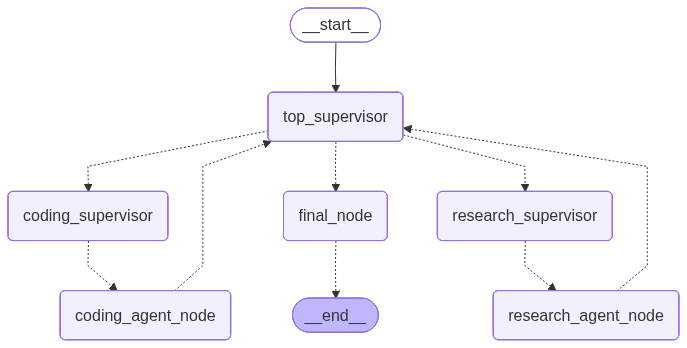

In [72]:
# ## 16. Visualize the Graph
#
# This displays the graph structure as an image.
#
# This is optional but useful in notebooks.


# %%
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [73]:
# ## 17. Run the Graph
#
# Initial state:
# - `research_notes` is empty
# - `coding_notes` is empty
# - `final_answer` is empty
#
# Execution flow:
#
# 1. Top supervisor sends work to research.
# 2. Research agent writes research notes.
# 3. Top supervisor sends work to coding.
# 4. Coding agent writes coding notes.
# 5. Top supervisor sends work to final node.
# 6. Final writer agent creates the report.


# %%
result = graph.invoke(
    {
        "user_request": "Research why a customer saw payment failed, duplicate charge, and refund delay.",
        "research_notes": "",
        "coding_notes": "",
        "final_answer": "",
    },
    config={"recursion_limit": 20},
)

print(result["final_answer"])

Research supervisor called
Research agent called
Coding supervisor called
Coding agent called
Final node called
<think>
Okay, let's tackle this report. The user wants a technical report based on the provided research and coding notes. The sections needed are Root Cause, Evidence, Code-Level Issue, Recommended Fix, and Test Cases.

First, the Root Cause. The main issues are payment failure, duplicate charge, and refund delay. From the research notes, the payment failure is due to a timeout after authorization. The duplicate charge comes from retry attempts during the timeout. The refund delay is because the settlement is pending. I need to connect these points clearly.

Next, Evidence. The research notes mention specific statuses like AUTHORIZED but CHECKOUT_TIMEOUT. Also, DUPLICATE_AUTHORIZATION being true but not settled. The coding notes explain the problem areas in the code. I should list these as evidence points.

Code-Level Issues: The payment failure's code doesn't check authoriz